2026-03-09 21:38:24.521854: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/amatthews/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.5099 - loss: 0.7166 - val_accuracy: 0.5512 - val_loss: 0.6908
Epoch 2/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.5563 - loss: 0.6869 - val_accuracy: 0.5521 - val_loss: 0.6850
Epoch 3/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.5538 - loss: 0.6846 - val_accuracy: 0.5718 - val_loss: 0.6785
Epoch 4/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.5540 - loss: 0.6841 - val_accuracy: 0.5937 - val_loss: 0.6741
Epoch 5/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.5678 - loss: 0.6840 - val_accuracy: 0.5458 - val_loss: 0.6863
Epoch 6/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.5597 - loss: 0.6839 - val_accuracy: 0.5744 - val_loss: 0.6810
Epoch 7/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.5611 - loss: 0.6838 - val_accuracy: 0.5955 - val_loss: 0.6780
Epoch 8/10
3119/3119 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.5695 - loss: 0.6838 - 

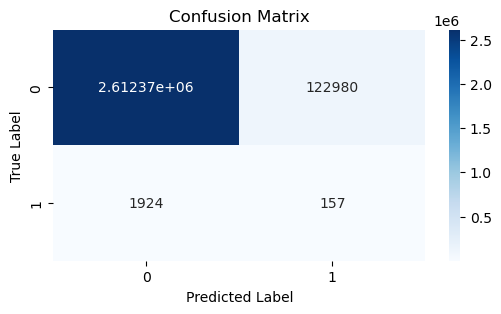

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
import tensorflow_decision_forests as tfdf


# -----------------------------
# Load Data
# -----------------------------

MODIS_FIRMS_TRAIN_VAL_TEST_DATASET = '../data/processed/modis_firms_train_val_test_dataset.npz'

data = np.load(MODIS_FIRMS_TRAIN_VAL_TEST_DATASET)

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

# -----------------------------
# Standard Scaler
# -----------------------------

scaler = StandardScaler()

# Fit on training data, transform all
X_train_scaled = scaler.fit_transform(X_train.astype(np.float32))
X_val_scaled = scaler.transform(X_val.astype(np.float32))
X_test_scaled = scaler.transform(X_test.astype(np.float32))

# -----------------------------
# Confusion Matrix
# -----------------------------

def plt_cnf_matrix(y_test,y_pred):
    
    # Confusion Matrix`
    cnf_matrix = confusion_matrix(y_test, y_pred)    
    
    
    # Confusion Matrix plot
    plt.figure(figsize = (15,3))
    plt.subplots_adjust(hspace = 0.5, wspace = 0.5)
    plt.subplot(1,2,1)
    sns.heatmap(cnf_matrix, annot = True, fmt = 'g', cmap = plt.cm.Blues)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    
    
    print('-'*25)
    print('Classification Report')
    print('-'*25)
    print(classification_report(y_test, y_pred))
    
# -----------------------------
# Logistic Regression (Baseline Model)
# -----------------------------

# class weight for imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}

# Train model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(X_train_scaled.shape[1],))
])
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
    )

history = model.fit(
    X_train_scaled,
    y_train.astype(np.float32),
    validation_data = (X_val_scaled, y_val.astype(np.float32)),
    epochs=10,
    batch_size=4096,
    class_weight=class_weight_dict,
    verbose=1
)

# Predict with optimal threshold
tflr_y_val_prob = model.predict(X_val_scaled, verbose=0).flatten()

# Find optimal threshold
precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, tflr_y_val_prob)
f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-8)
optimal_idx = np.argmax(f1_scores)
tflr_optimal_threshold = thresholds[optimal_idx]

# Final predictions
tflr_y_val_pred_optimal = (tflr_y_val_prob >= tflr_optimal_threshold).astype(int)

# Show results
print(f"Optimal Threshold: {tflr_optimal_threshold:.4f}")
plt_cnf_matrix(y_val, tflr_y_val_pred_optimal)
